In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


import joblib

In [20]:
df = pd.read_csv("placement.csv")
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


In [22]:
df.shape

(30000, 7)

In [23]:
df.isnull().sum()

years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64

In [24]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


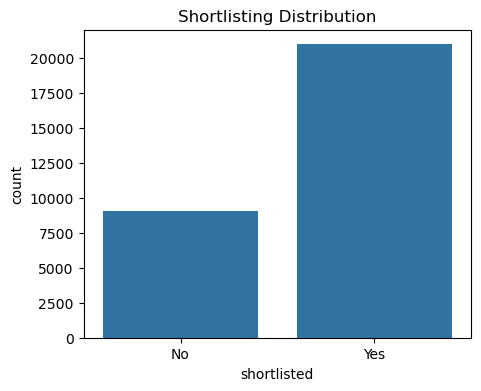

In [25]:
plt.figure(figsize=(5,4))
sns.countplot(x='shortlisted', data=df)
plt.title("Shortlisting Distribution")
plt.show()

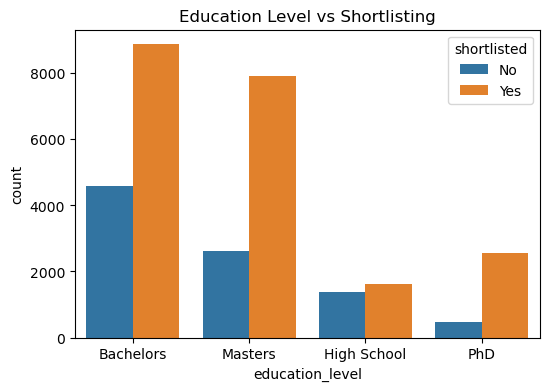

In [26]:
def visa():
    plt.figure(figsize=(6,4))
    sns.countplot(x='education_level', hue='shortlisted', data=df)
    plt.title("Education Level vs Shortlisting")
    plt.show()

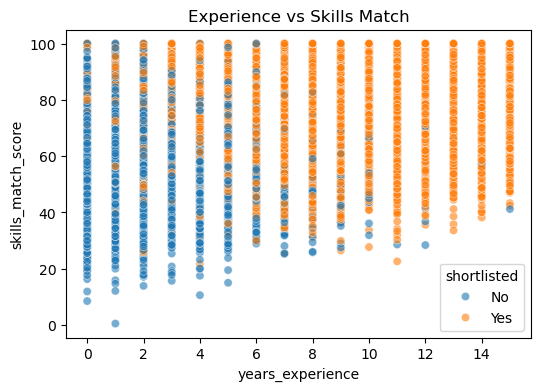

In [27]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='years_experience',
    y='skills_match_score',
    hue='shortlisted',
    data=df,
    alpha=0.6
)
plt.title("Experience vs Skills Match")
plt.show()

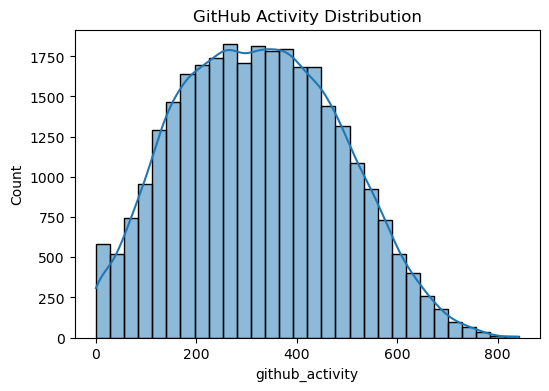

In [28]:
plt.figure(figsize=(6,4))
sns.histplot(df['github_activity'], bins=30, kde=True)
plt.title("GitHub Activity Distribution")
plt.show()

In [29]:
num_features = [
    'years_experience',
    'skills_match_score',
    'github_activity'
]

cat_features = ['education_level']
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [30]:
X = df.drop('shortlisted', axis=1)
y = df['shortlisted'].map({'No':0,'Yes':1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model_pipeline.fit(X_train, y_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:

y_pred = model_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred)*100)
print(classification_report(y_test, y_pred))


Accuracy: 89.7
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      1807
           1       0.92      0.93      0.93      4193

    accuracy                           0.90      6000
   macro avg       0.88      0.88      0.88      6000
weighted avg       0.90      0.90      0.90      6000



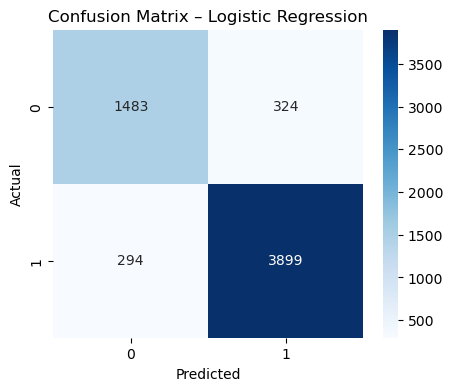

In [32]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

In [33]:
import pickle

In [37]:
pickle.dump(model_pipeline,open('placementHelp.pkl','wb'))
pickle.dump(df,open('datafr.pkl','wb'))